## ViT 데이터셋

In [5]:

from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

def subset_sampler(dataset, classes, max_len):
    target_idx=defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices=list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)
#fashion_mnist 데이터셋 내려받기
train_dataset=datasets.FashionMNIST("/Users/bluecloud/Documents/대학/유런",download=True,train=True)
test_dataset=datasets.FashionMNIST("/Users/bluecloud/Documents/대학/유런",download=True,train=False)
classes=train_dataset.classes #데이터세트에 포함된 속성
class_to_idx=train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset=subset_sampler( #서브 샘플링 수행
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset=subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

print(f"Training Data Size: {len(subset_train_dataset)}")
print(f"Testing Data Size: {len(subset_test_dataset)}")
print(train_dataset[0])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training Data Size: 10000
Testing Data Size: 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x169764D40>, 9)


/opt/anaconda3/lib/python3.12/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [7]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor=AutoImageProcessor.from_pretrained( 
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform=transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize( 
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda( 
            lambda x: torch.cat([x,x,x], 0)
        ),
        transforms.Normalize( #정규화
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size: {image_processor.size}")
print(f"mean: {image_processor.image_mean}")
print(f"std: {image_processor.image_std}")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size: {'height': 224, 'width': 224}
mean: [0.5, 0.5, 0.5]
std: [0.5, 0.5, 0.5]


In [9]:
from torch.utils.data import DataLoader

def collator(data, transform):
    images, labels=zip(*data)
    pixel_values=torch.stack([transform(image) for image in images])
    labels=torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}

train_dataloader=DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader=DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

batch=next(iter(train_dataloader))
for key, value in batch.items():
    print(f"{key}: {value.shape}")

pixel_values: torch.Size([32, 3, 224, 224])
labels: torch.Size([32])


# Swin TransFormer

In [28]:
#상대적 위치 편향 계산
import torch

window_size=2
coords_h=torch.arange(window_size)
coords_w=torch.arange(window_size)
coords=torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
coords_flatten=torch.flatten(coords, 1)
relative_coords=coords_flatten[:,:,None] - coords_flatten[:, None,:]

print(relative_coords)
print(relative_coords.shape)

tensor([[[ 0,  0, -1, -1],
         [ 0,  0, -1, -1],
         [ 1,  1,  0,  0],
         [ 1,  1,  0,  0]],

        [[ 0, -1,  0, -1],
         [ 1,  0,  1,  0],
         [ 0, -1,  0, -1],
         [ 1,  0,  1,  0]]])
torch.Size([2, 4, 4])


In [30]:
#X, Y축에 대한 위치 행렬
x_coords=relative_coords[0,:,:]
y_coords=relative_coords[1,:,:]

x_coords+=window_size-1
y_coords+=window_size-1
x_coords*=2*window_size-1
print(f"X축에 대한 행렬:\n{x_coords}\n")
print(f"Y축에 대한 행렬:\n{y_coords}\n")

relative_position_index=x_coords+y_coords
print(f"X, Y축에 대한 위치 행렬:\n{relative_position_index}")

X축에 대한 행렬:
tensor([[3, 3, 0, 0],
        [3, 3, 0, 0],
        [6, 6, 3, 3],
        [6, 6, 3, 3]])

Y축에 대한 행렬:
tensor([[1, 0, 1, 0],
        [2, 1, 2, 1],
        [1, 0, 1, 0],
        [2, 1, 2, 1]])

X, Y축에 대한 위치 행렬:
tensor([[4, 3, 1, 0],
        [5, 4, 2, 1],
        [7, 6, 4, 3],
        [8, 7, 5, 4]])


In [32]:
#X, Y축에 대한 상대적 위치 좌표 변환
num_heads=1
relative_position_bias_table=torch.Tensor(
    torch.zeros((2*window_size-1)*(2*window_size-1), num_heads)
)

relative_position_bias=relative_position_bias_table[relative_position_index.view(-1)]
relative_position_bias=relative_position_bias.view(
    window_size*window_size, window_size*window_size, -1
)
print(relative_position_bias.shape)

torch.Size([4, 4, 1])


In [34]:
#사전 학습된 스윈 트랜스포머 모델
from transformers import SwinForImageClassification

model=SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("L", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("| L", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                if sssub_name=="projection":
                    print("| | L", sssub_name, sssub_module)
                else:
                    print("| | L", sssub_name)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


swin
L embeddings
| L patch_embeddings
| | L projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
| L norm
| L dropout
L encoder
| L layers
| | L 0
| | L 1
| | L 2
| | L 3
L layernorm
L pooler
classifier


In [36]:
#패치 임베딩 모듈
batch=next(iter(train_dataloader))
print("이미지 차원:", batch["pixel_values"].shape)

patch_emb_output, shape=model.swin.embeddings.patch_embeddings(batch["pixel_values"])
print("모듈:", model.swin.embeddings.patch_embeddings)
print("패치 임베딩 차원:", patch_emb_output.shape)

이미지 차원: torch.Size([32, 3, 224, 224])
모듈: SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원: torch.Size([32, 3136, 96])


In [38]:
#스윈 트랜스포머 블록
for main_name, main_module in model.swin.encoder.layers[0].named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("L", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("| L", ssub_name)
     

blocks
L 0
| L layernorm_before
| L attention
| L drop_path
| L layernorm_after
| L intermediate
| L output
L 1
| L layernorm_before
| L attention
| L drop_path
| L layernorm_after
| L intermediate
| L output
downsample
L reduction
L norm


In [40]:
#SwinLayer 구조
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


In [42]:
#W-MSA, SW-MSA 모듈
print("패치 임베딩 차원:", patch_emb_output.shape)

W_MSA=model.swin.encoder.layers[0].blocks[0]
SW_MSA=model.swin.encoder.layers[0].blocks[1]

W_MSA_output=W_MSA(patch_emb_output, W_MSA.input_resolution)[0]
SW_MSA_output=SW_MSA(W_MSA_output, SW_MSA.input_resolution)[0]

print("W-MSA 결과 차원:", W_MSA_output.shape)
print("SW-MSA 결과 차원:", SW_MSA_output.shape)

패치 임베딩 차원: torch.Size([32, 3136, 96])
W-MSA 결과 차원: torch.Size([32, 3136, 96])
SW-MSA 결과 차원: torch.Size([32, 3136, 96])


In [44]:
#패치 병합
patch_merge=model.swin.encoder.layers[0].downsample
print("patch_merge 모듈: ", patch_merge)

output=patch_merge(SW_MSA_output, patch_merge.input_resolution)
print("patch_merge 결과 차원: ", output.shape)

patch_merge 모듈:  SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과 차원:  torch.Size([32, 784, 192])


In [46]:
#스윈 트랜스포머 모델 학습
from transformers import SwinForImageClassification

def subset_sampler(dataset, classes, max_len):
    target_idx=defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices=list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)

def model_init(classses, class_to_idx):
    model=SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model

def collator(data, transform):
    images, labels=zip(*data)
    pixel_values=torch.stack([transform(image) for image in images])
    labels=torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}
def compute_metrics(eval_pred):
    metric=evaluate.load("f1")
    predictions, labels=eval_pred
    predictions=np.argmax(predictions, axis=1)
    macro_f1=metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1
train_dataset=datasets.FashionMNIST("/Users/bluecloud/Documents/대학/유런",download=True,train=True)
test_dataset=datasets.FashionMNIST("/Users/bluecloud/Documents/대학/유런",download=True,train=False)
classes=train_dataset.classes
class_to_idx=train_dataset.class_to_idx

subset_train_dataset=subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset=subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor=AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform=transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)
args=TrainingArguments(
    output_dir="../models/Swin-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to="none",
)

trainer=Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/opt/anaconda3/lib/python3.12/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_53230/3017390164.py:91: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer=Trainer(
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You sh

Epoch,Training Loss,Validation Loss,F1
1,0.339800,0.279966,0.903615
2,0.239500,0.239625,0.916524
3,0.215400,0.220178,0.932262


TrainOutput(global_step=1875, training_loss=0.3552650187174479, metrics={'train_runtime': 2086.9063, 'train_samples_per_second': 14.375, 'train_steps_per_second': 0.898, 'total_flos': 7.4584635826176e+17, 'train_loss': 0.3552650187174479, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 8.912009  , -2.625224  , -0.22980575, ..., -2.6362522 ,
        -1.5829742 , -1.4968183 ],
       [ 4.224304  ,  0.94172573,  0.95496714, ..., -2.0228226 ,
        -0.9216379 , -2.7416775 ],
       [ 7.4125037 , -3.2689056 , -0.46522292, ..., -1.378173  ,
         0.41645163, -2.0457366 ],
       ...,
       [-0.98207057, -2.9122214 , -2.7152371 , ...,  1.3555809 ,
         0.37390405,  5.621233  ],
       [-0.62010825, -3.0038366 , -1.880342  , ...,  1.8865798 ,
        -2.668663  ,  9.064485  ],
       [-1.4159285 , -1.9250859 , -1.8805311 , ..., -1.0983036 ,
        -1.8249772 ,  8.795821  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

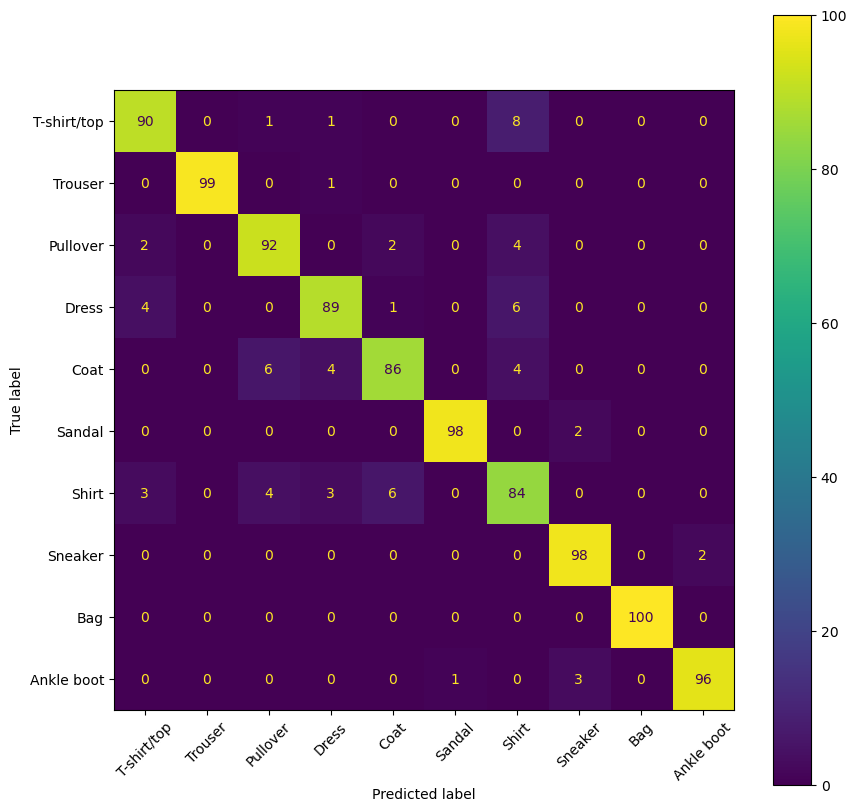

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs=trainer.predict(subset_test_dataset)
print(outputs)

y_true=outputs.label_ids
y_pred=outputs.predictions.argmax(1)

labels=list(classes)
matrix=confusion_matrix(y_true, y_pred)
display=ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_,ax=plt.subplots(figsize=(10,10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()